In [2]:
import pandas as pd

df = pd.read_csv("/Users/dahee/Desktop/JOB/funnel-analysis/data/2020-Apr.csv", nrows = 100000)
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-04-01 00:00:00 UTC,view,1201465,2232732101407408685,apparel.shoes.slipons,samsung,230.38,568984877,e2456cef-2d4f-42b9-a53a-8893cb0c6851
1,2020-04-01 00:00:01 UTC,view,1307156,2053013554658804075,electronics.audio.headphone,apple,1352.67,514955500,38f43134-de83-4710-ae0a-326677d292c6
2,2020-04-01 00:00:01 UTC,view,1480477,2053013563835941749,appliances.kitchen.refrigerators,apple,1184.05,633645770,16aba270-b3c2-4b23-be0a-b7c80bc9da9e
3,2020-04-01 00:00:02 UTC,view,1307050,2053013554658804075,electronics.audio.headphone,apple,1724.34,564933778,05b443bd-e68a-4d72-b971-80bd31109cb8
4,2020-04-01 00:00:03 UTC,view,9500109,2232732104175649385,apparel.scarf,defender,25.05,530206135,e3c1fb4b-0a7e-457d-a0cf-5d1479e9aafc


In [3]:
df.columns

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')

In [4]:
df["event_type"].value_counts()

event_type
view        93653
cart         4829
purchase     1518
Name: count, dtype: int64

In [5]:
df["event_time"] = pd.to_datetime(df["event_time"])

In [6]:
view_users = df[df["event_type"] == "view"]["user_id"].nunique()
cart_users = df[df["event_type"] == "cart"]["user_id"].nunique()
purchase_users = df[df["event_type"] == "purchase"]["user_id"].nunique()

view_users, cart_users, purchase_users
#A lot of people view it, but they barely even buy it

(17620, 2534, 1203)

In [7]:
#Conversion rate
view_to_cart = cart_users / view_users
cart_to_purchase = purchase_users / cart_users

view_to_cart, cart_to_purchase
#Where does it fall the most?
#view -> cart: 14%, cart -> purchase: 47%


(0.1438138479001135, 0.47474348855564324)

In [8]:
#Drop-off
drop_view = 1 - view_to_cart
drop_cart = 1 - cart_to_purchase

drop_view, drop_cart
#Whether it falls off the view or the cart

(0.8561861520998865, 0.5252565114443568)

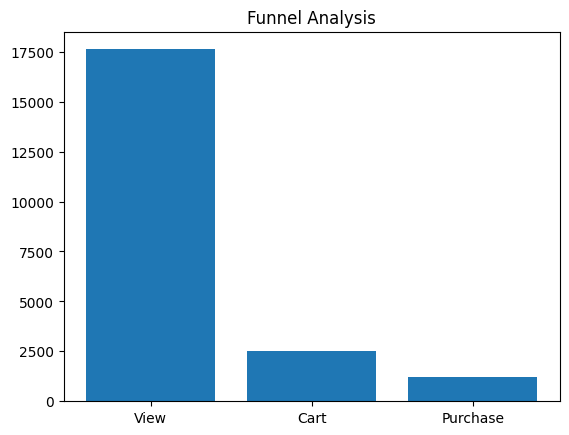

In [9]:
import matplotlib.pyplot as plt

stages = ["View", "Cart", "Purchase"]
values = [view_users, cart_users, purchase_users]

plt.bar(stages, values)
plt.title("Funnel Analysis")
plt.show()

<Axes: xlabel='hour'>

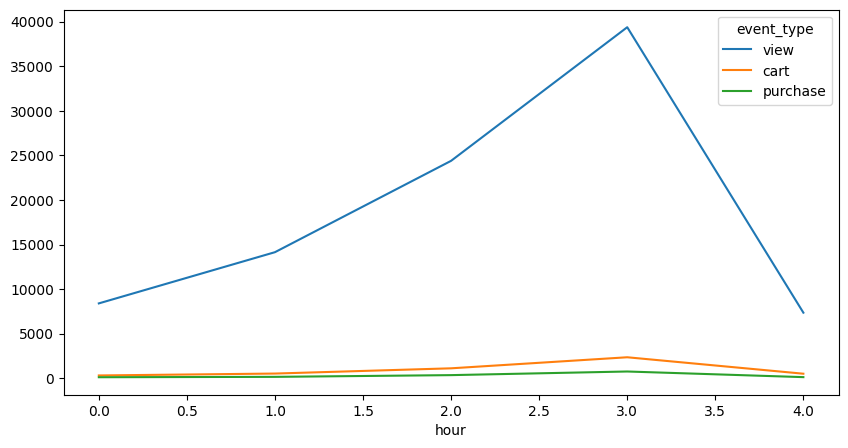

In [10]:
#When do people buy a lot / not buy a lot?
df["hour"] = df["event_time"].dt.hour
df['hour'].unique()
df_hour = df.groupby("hour")["event_type"].value_counts().unstack().fillna(0)
df_hour[["view", "cart", "purchase"]].plot(figsize=(10,5))

#Night time view high, purchase low → “Just browsing”
#But this is the only sample representative Midnight -> have to analyze with more samples to see what happen to during the daytime

In [11]:
#How much does a user once come in behave? (How long they stay once they come)
session_counts = df.groupby("user_session")["event_type"].count()
session_counts.describe()
#High count -> high engagement

count    19248.000000
mean         5.195345
std          7.554102
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        219.000000
Name: event_type, dtype: float64

In [12]:
#How long do they think about buying it?
df_sorted = df.sort_values(["user_id", "event_time"])
purchase_df = df_sorted[df_sorted["event_type"] == "purchase"]

first_view = df_sorted[df_sorted["event_type"] == "view"].groupby("user_id")["event_time"].min()
purchase_time = purchase_df.groupby("user_id")["event_time"].min()

time_to_purchase = (purchase_time - first_view).dropna()
time_to_purchase.describe()
#Most users convert quickly, with a median time to purchase of around 3.5 minutes, suggesting impulsive buying behavior. (right-skewed)
#However, a smaller group of users takes significantly longer, indicating a more deliberate decision process. 
#This highlights the presence of distinct user segments with different engagement patterns.
#Some negative values indicate data inconsistency or event ordering issues, which should be cleaned before modeling.

count                         1198
mean     0 days 00:09:37.504173622
std      0 days 00:19:22.392544410
min              -1 days +23:57:46
25%                0 days 00:01:41
50%         0 days 00:03:31.500000
75%         0 days 00:08:19.500000
max                0 days 03:45:44
Name: event_time, dtype: object

In [13]:
#What products sell well?
df["category_code"].value_counts().head(10)
df[df["event_type"] == "purchase"]["category_code"].value_counts().head(10)

#There are many products that are practical and need immediate


category_code
construction.tools.light            576
electronics.audio.headphone         162
appliances.personal.massager         57
sport.bicycle                        51
apparel.shoes                        38
electronics.clocks                   37
appliances.kitchen.refrigerators     31
furniture.kitchen.table              26
apparel.shoes.slipons                23
appliances.environment.vacuum        21
Name: count, dtype: int64

In [14]:
view = df[df["event_type"]=="view"].groupby("category_code")["user_id"].count()
purchase = df[df["event_type"]=="purchase"].groupby("category_code")["user_id"].count()

conversion = (purchase / view).sort_values(ascending=False)

conversion.head(10)

category_code
appliances.ironing_board               0.115385
auto.accessories.anti_freeze           0.076923
apparel.shoes.espadrilles              0.036585
construction.tools.painting            0.035714
apparel.trousers                       0.029032
construction.tools.light               0.028885
appliances.sewing_machine              0.025000
electronics.audio.music_tools.piano    0.022222
kids.carriage                          0.021739
construction.tools.saw                 0.021645
Name: user_id, dtype: float64